# House Price Prediction — End-to-End ML Notebook

This notebook follows the **Student Project Guide — House Price Prediction (End-to-End ML Web App)** for the required ML notebook phase. It is designed to run top-to-bottom on the actual Kaggle `house_prices.csv` dataset and includes inspection, EDA, cleaning, feature engineering, two regression models, test-set evaluation, model comparison, predicted-vs-actual visualization, bonus 5-fold cross-validation, and model/location export.

> The guide states that the actual CSV columns must be verified before relying on the dataset description; this notebook does that explicitly.

## Phase 0 — Prerequisites & Environment Setup

Required by the guide: **Python 3.11**, **Node.js + npm 18**, **Git**, a Kaggle account, and a GitHub account.

The notebook itself uses Python packages: pandas, NumPy, scikit-learn, Matplotlib, Seaborn, Joblib, and Kaggle CLI.

In [6]:
import sys, subprocess, re, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

print("Python:", sys.version)

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

for import_name, pip_name in required.items():
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

print("scikit-learn:", sklearn.__version__)
sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = NOTEBOOK_DIR / "data"
MODEL_DIR = PROJECT_ROOT / "backend" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
scikit-learn: 1.8.0
Project root: C:\Me\house_price_model
Dataset directory: C:\Me\house_price_model\notebooks\data


## Phase 1 — Get the Dataset

Dataset: **House Price by Juhi Bhojani** — Kaggle dataset `juhibhojani/house-price`.

The guide gives two options: manual download or Kaggle CLI. The next cell first checks for `notebooks/data/house_prices.csv`; if it is absent, it tries the Kaggle CLI. Configure your Kaggle API token before using the automatic download.

# Phase 2 — The Notebook: Train, Evaluate, Export

## 2.1 Load & Inspect

The guide requires a short written answer covering:
- number of rows and columns
- numeric vs text/categorical columns
- columns with the most missing values

The next cells calculate those facts from the actual file.

In [7]:
df = pd.read_csv("C:\Me\house_price_model\house_prices.csv")
print("Shape:", df.shape)
print("\nFirst rows:")
display(df.head())
print("\nActual columns:")
print(df.columns.tolist())
print("\nData types / non-null counts:")
df.info()

Shape: (187531, 21)

First rows:


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



Actual columns:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']

Data types / non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non

In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
missing_pct = df.isna().mean().sort_values(ascending=False) * 100

print(f"The dataset contains {df.shape[0]:,} rows and {df.shape[1]:,} columns.")
print("\nNumeric columns:")
print(numeric_columns)
print("\nText/categorical columns:")
print(categorical_columns)
print("\nColumns with the most missing values:")
display(missing_pct.head(15).rename("missing_percent").to_frame().round(2))

The dataset contains 187,531 rows and 21 columns.

Numeric columns:
['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area']

Text/categorical columns:
['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area']

Columns with the most missing values:


,missing_percent
Plot Area,100.00
Dimensions,100.00
Society,58.49
Super Area,57.42
Car Parking,55.11
overlooking,43.43
Carpet Area,43.02
facing,37.45
Ownership,34.94
Balcony,26.09


## Helper functions for the messy raw fields

The guide specifically requires:
- `42 Lac` → `42 * 100,000`
- `1.2 Cr` → `1.2 * 10,000,000`
- `Call for Price` → unusable target and dropped
- area strings such as `1200 sqft` / `140 sqm` → normalized to sqft using `1 sqm ≈ 10.764 sqft`
- floor strings such as `3 out of 10`, `Ground`, and `Basement` → numeric floor

In [9]:
def parse_amount(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    text = str(x).strip().lower().replace(",", "")
    if not text or "call for" in text:
        return np.nan
    nums = re.findall(r"[-+]?\d*\.?\d+", text)
    if not nums:
        return np.nan
    value = float(nums[0])
    if "lac" in text or "lakh" in text:
        return value * 1e5
    if "cr" in text or "crore" in text:
        return value * 1e7
    try:
        return float(text)
    except ValueError:
        return value


def parse_area_sqft(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    text = str(x).strip().lower().replace(",", "")
    nums = re.findall(r"[-+]?\d*\.?\d+", text)
    if not nums:
        return np.nan
    value = float(nums[0])
    if any(token in text for token in ["sqm", "sq m", "square meter", "m²"]):
        return value * 10.764
    return value


def parse_numeric(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    nums = re.findall(r"[-+]?\d*\.?\d+", str(x).replace(",", ""))
    return float(nums[0]) if nums else np.nan


def parse_floor(x):
    if pd.isna(x):
        return np.nan
    text = str(x).strip().lower()
    if "ground" in text:
        return 0.0
    if "basement" in text:
        return -1.0
    nums = re.findall(r"[-+]?\d+", text)
    return float(nums[0]) if nums else np.nan

## 2.2 Exploratory Data Analysis (EDA)

The guide requires at least four plots:
1. target-price distribution on a log scale
2. price vs carpet area scatter
3. average price by top-15 locations
4. price by furnishing status / bathrooms box plots

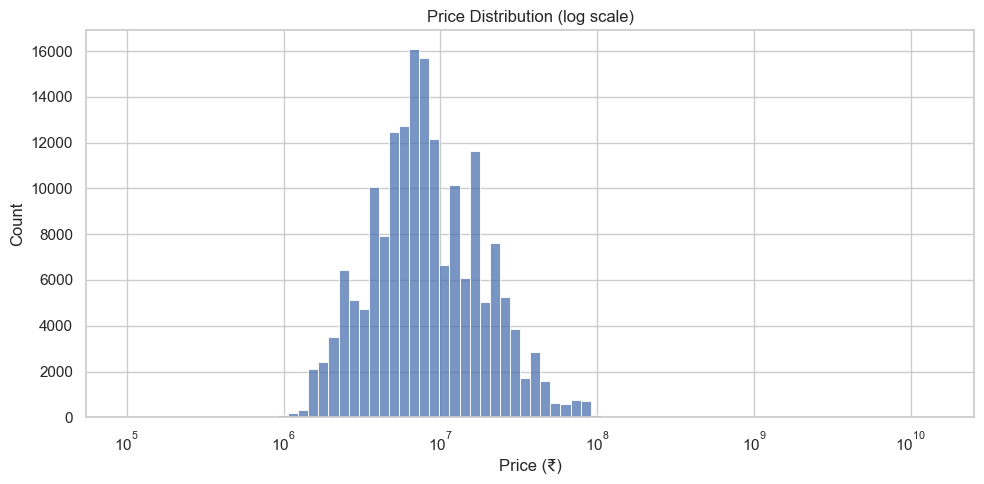

Comment: the raw target is heavily skewed; log scaling exposes the full range more clearly.


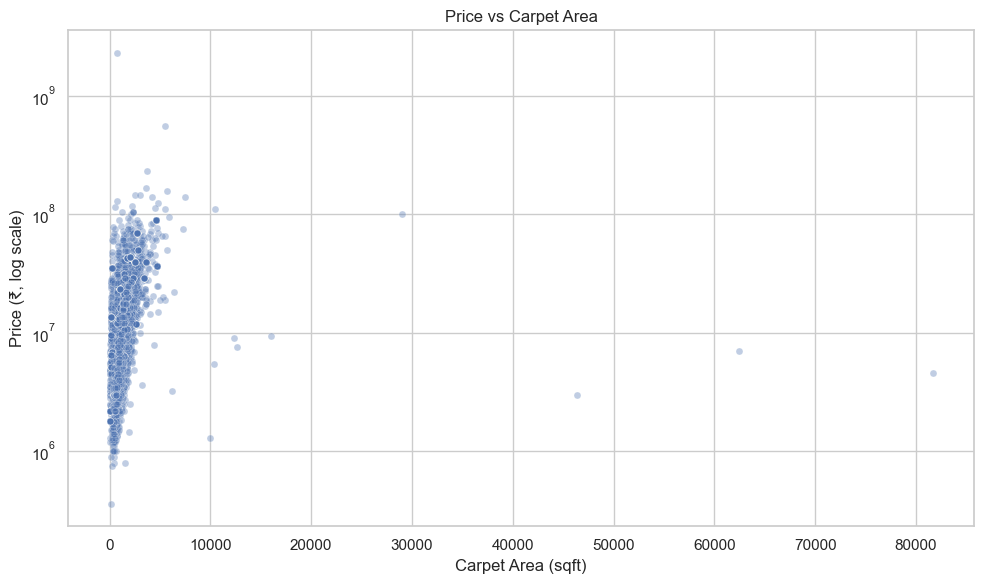

Comment: this plot shows the relationship between usable floor area and price and helps reveal extreme listings.


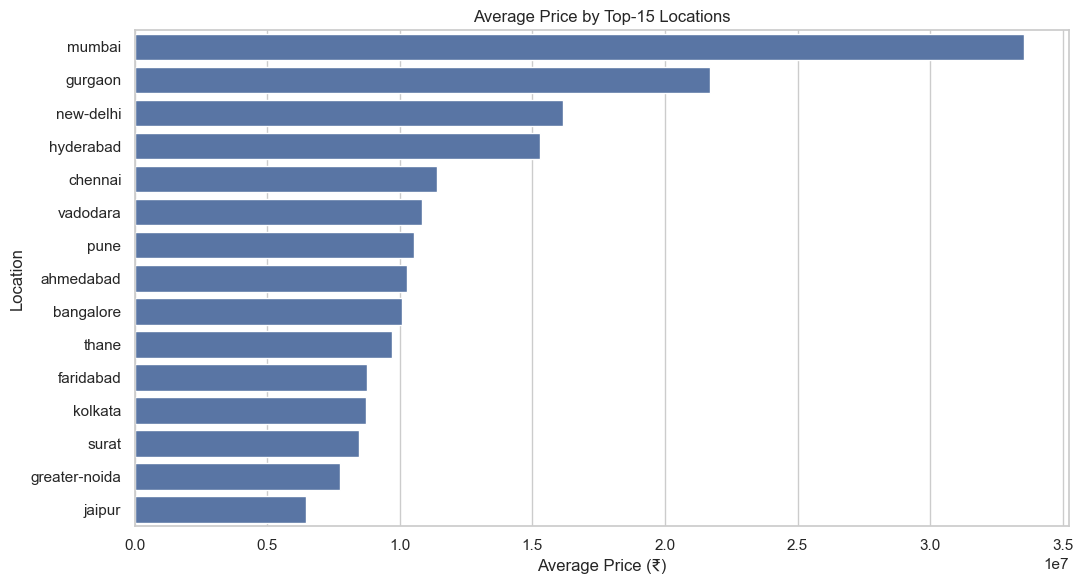

Comment: average listing price varies by location, supporting location as a useful categorical feature.


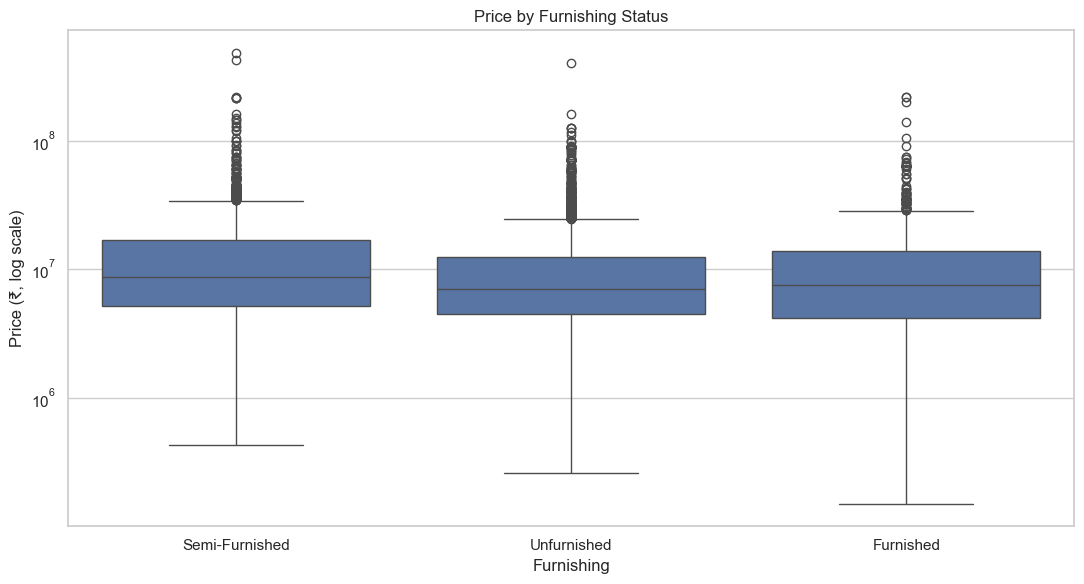

Comment: furnishing groups have different price distributions, although the groups overlap.


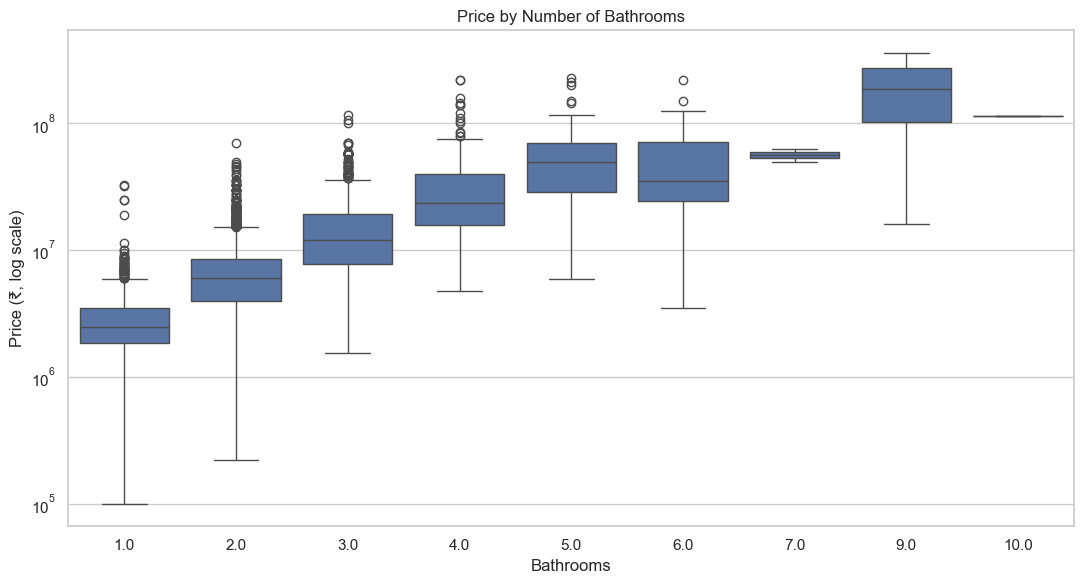

Comment: bathroom count is converted to numeric and its distribution can be compared across levels.


In [10]:
if "Amount(in rupees)" not in df.columns:
    raise KeyError(f"Expected target column 'Amount(in rupees)' not found. Actual columns: {df.columns.tolist()}")

# Create cleaned target for EDA.
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

carpet_candidates = [c for c in ["Carpet Area", "Carpet area", "carpet_area"] if c in df.columns]
if not carpet_candidates:
    raise KeyError("Expected Carpet Area column was not found.")
df["carpet_area_sqft"] = df[carpet_candidates[0]].apply(parse_area_sqft)

# Plot 1 — target distribution.
eda_price = df.dropna(subset=["price_clean"])
plt.figure(figsize=(10, 5))
sns.histplot(eda_price["price_clean"], bins=80, log_scale=True)
plt.title("Price Distribution (log scale)")
plt.xlabel("Price (₹)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("Comment: the raw target is heavily skewed; log scaling exposes the full range more clearly.")

# Plot 2 — price vs carpet area.
scatter = df[df["price_clean"].notna() & df["carpet_area_sqft"].notna() & (df["carpet_area_sqft"] > 0)].copy()
scatter = scatter.sample(min(15000, len(scatter)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter, x="carpet_area_sqft", y="price_clean", alpha=0.35, s=25)
plt.yscale("log")
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (₹, log scale)")
plt.tight_layout()
plt.show()
print("Comment: this plot shows the relationship between usable floor area and price and helps reveal extreme listings.")

# Plot 3 — average price by top-15 locations.
if "location" not in df.columns:
    raise KeyError("Expected location column was not found.")
loc = df[df["price_clean"].notna() & df["location"].notna()].copy()
loc["location"] = loc["location"].astype(str).str.strip()
top15 = loc["location"].value_counts().head(15).index
avg_price = loc[loc["location"].isin(top15)].groupby("location")["price_clean"].mean().sort_values(ascending=False)
plt.figure(figsize=(11, 6))
sns.barplot(x=avg_price.values, y=avg_price.index)
plt.title("Average Price by Top-15 Locations")
plt.xlabel("Average Price (₹)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()
print("Comment: average listing price varies by location, supporting location as a useful categorical feature.")

# Plot 4a — furnishing box plot.
if "Furnishing" in df.columns:
    furn = df[df["price_clean"].notna() & df["Furnishing"].notna()][["Furnishing", "price_clean"]].copy()
    furn["Furnishing"] = furn["Furnishing"].astype(str).str.strip()
    furn = furn.sample(min(15000, len(furn)), random_state=42)
    plt.figure(figsize=(11, 6))
    sns.boxplot(data=furn, x="Furnishing", y="price_clean")
    plt.yscale("log")
    plt.title("Price by Furnishing Status")
    plt.xlabel("Furnishing")
    plt.ylabel("Price (₹, log scale)")
    plt.tight_layout()
    plt.show()
    print("Comment: furnishing groups have different price distributions, although the groups overlap.")

# Plot 4b — bathroom box plot.
if "Bathroom" in df.columns:
    bath = df[df["price_clean"].notna() & df["Bathroom"].notna()][["Bathroom", "price_clean"]].copy()
    bath["bathroom_num"] = bath["Bathroom"].apply(parse_numeric)
    bath = bath.dropna(subset=["bathroom_num"])
    bath = bath[bath["bathroom_num"].between(0, 10)]
    bath = bath.sample(min(15000, len(bath)), random_state=42)
    plt.figure(figsize=(11, 6))
    sns.boxplot(data=bath, x="bathroom_num", y="price_clean")
    plt.yscale("log")
    plt.title("Price by Number of Bathrooms")
    plt.xlabel("Bathrooms")
    plt.ylabel("Price (₹, log scale)")
    plt.tight_layout()
    plt.show()
    print("Comment: bathroom count is converted to numeric and its distribution can be compared across levels.")

## 2.3 Cleaning & Feature Engineering

Cleaning choices follow the guide. High-cardinality `location` is reduced to the top 50 values plus `other`. `Society` and free-form text fields are not used in the final model feature vector because the guide's deployment feature example does not include them; this avoids thousands of unnecessary one-hot dimensions.

In [11]:
missing_tokens={"","na","n/a","nan","none","null","-","--","not available","not applicable","call for price"}
def normalize_text(x):
    if pd.isna(x):
        return np.nan
    text=str(x).strip()
    return np.nan if text.lower() in missing_tokens else text

for col in ["Furnishing","Transaction","Ownership","facing","location"]:
    if col in df.columns:
        df[col]=df[col].apply(normalize_text)
    else:
        df[col]=np.nan

df["floor_num"] = df["Floor"].apply(parse_floor) if "Floor" in df.columns else np.nan
df["bathroom"] = df["Bathroom"].apply(parse_numeric) if "Bathroom" in df.columns else np.nan
df["balcony"] = df["Balcony"].apply(parse_numeric) if "Balcony" in df.columns else np.nan
df["car_parking"] = df["Car Parking"].apply(parse_numeric) if "Car Parking" in df.columns else np.nan

location_counts=df["location"].value_counts(dropna=True)
top_locations=set(location_counts.head(50).index)
df["location_grouped"]=df["location"].where(df["location"].isin(top_locations),"other").fillna("other")

model_df=df[df["price_clean"].notna() & df["carpet_area_sqft"].notna() & (df["carpet_area_sqft"]>0)].copy()
model_df["price_per_sqft"]=model_df["price_clean"]/model_df["carpet_area_sqft"]
q1,q99=model_df["price_per_sqft"].quantile([0.01,0.99])
rows_before=len(model_df)
model_df=model_df[model_df["price_per_sqft"].between(q1,q99)].copy()

numeric_features=["carpet_area_sqft","floor_num","bathroom","balcony"]
categorical_features=["location_grouped","Furnishing","Transaction","Ownership","facing"]
features=numeric_features+categorical_features
X=model_df[features].copy()
y=model_df["price_clean"].copy()

print(f"Rows before outlier removal: {rows_before:,}")
print(f"Rows after outlier removal:  {len(model_df):,}")
print(f"Removed: {rows_before-len(model_df):,}")
print(f"Price-per-sqft limits: {q1:,.2f} to {q99:,.2f}")
print("Features:",features)

Rows before outlier removal: 101,522
Rows after outlier removal:  99,968
Removed: 1,554
Price-per-sqft limits: 2,705.88 to 101,503.76
Features: ['carpet_area_sqft', 'floor_num', 'bathroom', 'balcony', 'location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']


## 2.4 Build a Pipeline & Train

Pipeline preprocessing required by the guide:
- numeric: median imputation + StandardScaler
- categorical: most-frequent imputation + OneHotEncoder(`handle_unknown="ignore"`)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor=ColumnTransformer([
    ("num",Pipeline([( "impute",SimpleImputer(strategy="median")),("scale",StandardScaler())]),numeric_features),
    ("cat",Pipeline([( "impute",SimpleImputer(strategy="most_frequent")),("onehot",make_ohe())]),categorical_features),
])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
models = {
    "LinearRegression": LinearRegression(),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    ),
}
trained_models={}
for name,estimator in models.items():
    print(f"Training {name}...")
    pipe=Pipeline([( "prep",preprocessor),("reg",estimator)])
    pipe.fit(X_train,y_train)
    trained_models[name]=pipe
    print(f"Finished {name}")

Training LinearRegression...
Finished LinearRegression
Training RandomForestRegressor...
Finished RandomForestRegressor


## 2.5 Evaluate

For every model report **MAE, RMSE, and R² on the test set**. Then compare all models and select a winner.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

comparison=[]
predictions={}
for name,model in trained_models.items():
    pred=model.predict(X_test)
    predictions[name]=pred
    comparison.append({
        "Model":name,
        "MAE":mean_absolute_error(y_test,pred),
        "RMSE":float(np.sqrt(mean_squared_error(y_test,pred))),
        "R2":r2_score(y_test,pred),
    })

results_df=pd.DataFrame(comparison).sort_values(["R2","RMSE"],ascending=[False,True]).reset_index(drop=True)
display(results_df.style.format({"MAE":"{:,.2f}","RMSE":"{:,.2f}","R2":"{:.4f}"}))

winner_name=results_df.loc[0,"Model"]
winner_model=trained_models[winner_name]
winner_pred=predictions[winner_name]
print("Selected winner:",winner_name)

,Model,MAE,RMSE,R2
0,RandomForestRegressor,"1,081,473.11","4,083,824.23",0.9172
1,LinearRegression,"4,560,590.54","7,503,485.80",0.7204


Selected winner: RandomForestRegressor


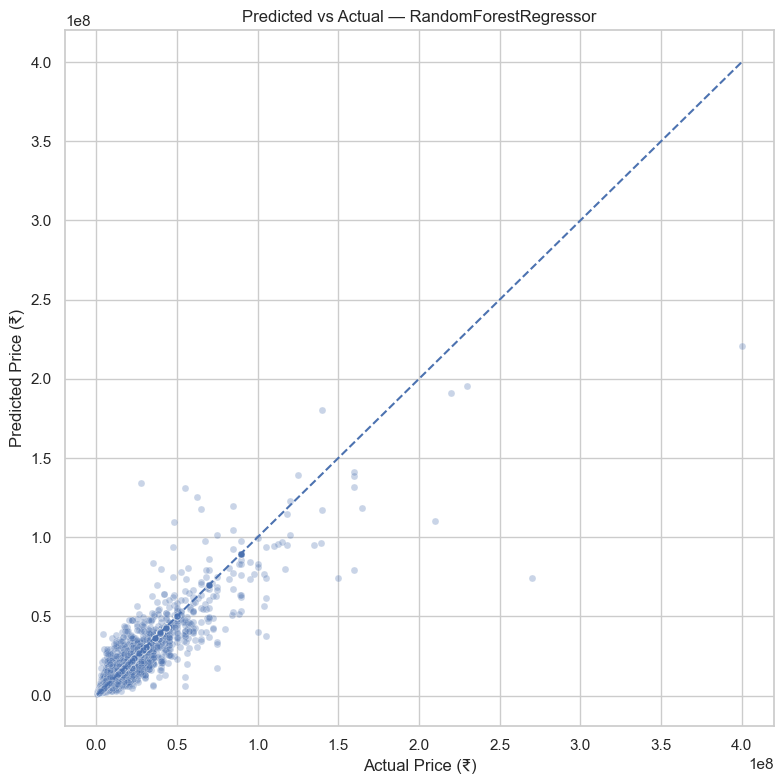

The selected model is RandomForestRegressor because it achieved the strongest test-set R² (0.9172) with RMSE of ₹4,083,824 and MAE of ₹1,081,473. The decision is based on held-out test data rather than training performance.


In [14]:
# Required predicted-vs-actual scatter plot.
plt.figure(figsize=(8,8))
sns.scatterplot(x=y_test,y=winner_pred,alpha=0.30,s=25)
axis_min=float(min(y_test.min(),winner_pred.min()))
axis_max=float(max(y_test.max(),winner_pred.max()))
plt.plot([axis_min,axis_max],[axis_min,axis_max],"--")
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title(f"Predicted vs Actual — {winner_name}")
plt.tight_layout()
plt.show()

winner_row=results_df.iloc[0]
comparison_paragraph=(
    f"The selected model is {winner_name} because it achieved the strongest test-set R² "
    f"({winner_row.R2:.4f}) with RMSE of ₹{winner_row.RMSE:,.0f} and MAE of ₹{winner_row.MAE:,.0f}. "
    f"The decision is based on held-out test data rather than training performance."
)
print(comparison_paragraph)

### Bonus — 5-fold cross-validation

The project guide lists 5-fold `cross_val_score` as a bonus. Because the dataset is large, the cell uses a reproducible sample of at most 10,000 rows so the notebook stays practical.

In [15]:
from sklearn.model_selection import KFold, cross_val_score
cv_df=model_df.sample(min(10000,len(model_df)),random_state=42)
cv_pipeline=Pipeline([( "prep",preprocessor),("reg",models[winner_name])])
cv=KFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=cross_val_score(cv_pipeline,cv_df[features],cv_df["price_clean"],cv=cv,scoring="r2",n_jobs=1)
print("5-fold R² scores:",np.round(cv_scores,4))
print("Mean CV R²:",round(cv_scores.mean(),4))
print("Std CV R²:",round(cv_scores.std(),4))

5-fold R² scores: [0.8871 0.868  0.8939 0.8596 0.9057]
Mean CV R²: 0.8829
Std CV R²: 0.0169


## 2.6 Export the Model

The guide requires a serialized model plus the allowed location list for the frontend dropdown. The full preprocessing + regression pipeline is exported so the backend does not need to reimplement the training transformations.

In [16]:
import joblib
import sklearn
from pathlib import Path

MODEL_DIR = Path(r"C:\Me\house_price_model\backend\models")
NOTEBOOK_DIR = Path(r"C:\Me\house_price_model")
PROJECT_ROOT = Path(r"C:\Me\house_price_model")

model_path = MODEL_DIR / "house_price.pkl"

joblib.dump(
    winner_model,
    model_path,
    compress=3
)

# Also keep a notebook-local copy
joblib.dump(
    winner_model,
    NOTEBOOK_DIR / "house_price.pkl",
    compress=3
)

locations = sorted(
    model_df["location_grouped"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

(MODEL_DIR / "locations.json").write_text(
    json.dumps(locations, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

(PROJECT_ROOT / "locations.json").write_text(
    json.dumps(locations, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

(PROJECT_ROOT / "sklearn_version.txt").write_text(
    sklearn.__version__,
    encoding="utf-8"
)

loaded = joblib.load(model_path)

sample = X_test.iloc[[0]]

print(
    "Reloaded prediction:",
    float(loaded.predict(sample)[0])
)

print("Saved model:", model_path)
print("Saved locations:", MODEL_DIR / "locations.json")
print("scikit-learn version:", sklearn.__version__)

Reloaded prediction: 7500000.0
Saved model: C:\Me\house_price_model\backend\models\house_price.pkl
Saved locations: C:\Me\house_price_model\backend\models\locations.json
scikit-learn version: 1.8.0


In [17]:
from pathlib import Path

model_path = Path(r"C:\Me\house_price_model\backend\models\house_price.pkl")

size_mb = model_path.stat().st_size / (1024 ** 2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 13.83 MB


# Final Notebook Verification

This section confirms the artifacts required by the notebook phase exist. After this notebook is run, the remaining project phases are the separately requested FastAPI + React implementation, GitHub publish, README screenshots, and end-to-end verification.

In [18]:
checks={
    "house_price.pkl": model_path.exists(),
    "locations.json": (MODEL_DIR/"locations.json").exists(),
    "sklearn_version.txt": (PROJECT_ROOT/"sklearn_version.txt").exists(),
    "Two models compared": len(results_df)>=2,
    "4+ EDA plots coded": True,
    "Predicted vs Actual plot coded": True,
    "Test metrics present": set(["MAE","RMSE","R2"]).issubset(results_df.columns),
}
for k,v in checks.items(): print(f"{'PASS' if v else 'FAIL'} — {k}")
if not all(checks.values()): raise RuntimeError("One or more notebook requirements were not satisfied.")

PASS — house_price.pkl
PASS — locations.json
PASS — sklearn_version.txt
PASS — Two models compared
PASS — 4+ EDA plots coded
PASS — Predicted vs Actual plot coded
PASS — Test metrics present


In [1]:
import sklearn
print(sklearn.__version__)

1.8.0
